In [1]:
import pandas as pd
import numpy as np
import time
import psutil
import threading
import os
import folium
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

/home/katharian/.local/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


## Classe para monitoramento de hardware

In [2]:
class MonitorHardware:
    def __init__(self, label="Tarefa", intervalo=0.1):
        self.label = label
        self.intervalo = intervalo
        self.monitorando = False
        self.dados = {
            "cpu_avg": 0, "cpu_max": 0,
            "ram_avg": 0, "ram_max": 0
        }
        self._thread = None
        self.num_cores = psutil.cpu_count(logical=True)

    def __enter__(self):
        self.monitorando = True
        self._thread = threading.Thread(target=self._coletar_metricas)
        self._thread.start()
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.monitorando = False
        if self._thread:
            self._thread.join()
        
        # Resumo ao sair do bloco
        print(f"[{self.label}] CPU Méd: {self.dados['cpu_avg']:.1f}% (Max: {self.dados['cpu_max']:.1f}%) | "
              f"RAM Méd: {self.dados['ram_avg']:.1f}MB (Max: {self.dados['ram_max']:.1f}MB)")

    def _coletar_metricas(self):
        processo_pai = psutil.Process(os.getpid())
        cpus = []
        rams = []
        
        # Primeira leitura de CPU é descarte
        processo_pai.cpu_percent(interval=None)
        
        while self.monitorando:
            try:
                # Pega processo atual e filhos (importante para n_jobs=-1 do sklearn)
                filhos = processo_pai.children(recursive=True)
                processos = [processo_pai] + filhos
                
                # Soma CPU e RAM de todos os processos
                cpu_total = sum(p.cpu_percent(interval=None) for p in processos)
                ram_total = sum(p.memory_info().rss for p in processos) / (1024 * 1024) # MB

                cpu_normalized = cpu_total / self.num_cores
                
                cpus.append(cpu_normalized)
                rams.append(ram_total)
                
            except (psutil.NoSuchProcess, psutil.AccessDenied):
                pass 
            
            time.sleep(self.intervalo)

        # Estatísticas Finais
        if cpus:
            self.dados['cpu_avg'] = sum(cpus) / len(cpus)
            self.dados['cpu_max'] = max(cpus)
        if rams:
            self.dados['ram_avg'] = sum(rams) / len(rams)
            self.dados['ram_max'] = max(rams)

## Carregamento dos dados

In [3]:
files = [
    "../data/processed/teste_eco_10_01_4.csv",
    "../data/processed/teste_nor_10_01.csv",
    "../data/processed/teste_tur_10_01.csv"
]

df_list = []
for file_path in files:
    try:
        temp_df = pd.read_csv(file_path)
        df_list.append(temp_df)
        print(f"Carregado: {file_path}")
    except FileNotFoundError:
        print(f"ERRO: Arquivo {file_path} não encontrado.")

if not df_list:
    raise ValueError("Nenhum arquivo foi carregado. Verifique os caminhos.")

df = pd.concat(df_list, ignore_index=True)

Carregado: ../data/processed/teste_eco_10_01_4.csv
Carregado: ../data/processed/teste_nor_10_01.csv
Carregado: ../data/processed/teste_tur_10_01.csv


## Processamento dos dados

In [4]:
# Mapear os modos para valores numéricos
def map_mode(val):
    val = str(val).lower()
    if 'eco' in val: return 0
    if 'nor' in val: return 1
    if 'tur' in val: return 2
    return -1 # Caso de erro

df['mode'] = df['testCase'].apply(map_mode)

# Calcular o tempo decorrido em segundos desde o início de teste em cada modo
df = df.sort_values(by=['testCase', 'receivedAtMs'])
df['elapsed_time_s'] = df.groupby('testCase')['receivedAtMs'].transform(lambda x: (x - x.min()) / 1000.0)

#Deixando só as colunas relevantes
cols_to_drop = ['id', 'deviceId', 'sampleId', 'motorC', 'testCase', 
                'receivedAt', 'receivedAtMs', 'headingDeg', 'accuracyM']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

df = df.rename(columns={
    'referenceC': 'temp_amb',
    'speedMps': 'speed',
    'lng': 'lon',
    'accel_x': 'accX', 
    'accel_y': 'accY', 
    'accel_z': 'accZ',
    'batteryC': 'temp_battery'
})

print(f"Dataset processado: {df.shape[0]} registros.")
df.head()

Dataset processado: 1010 registros.


,lat,lon,speed,temp_battery,temp_amb,accX,accY,accZ,mode,elapsed_time_s
0,-8.055623,-34.951128,0.000000,32.69,30.44,1084,332,165,0,0.000
1,-8.055622,-34.951125,0.000000,32.69,30.44,1094,333,130,0,1.022
2,-8.055609,-34.951112,0.740566,32.75,30.50,1093,334,134,0,2.998
3,-8.055603,-34.951105,0.394090,32.69,30.50,1094,333,137,0,4.022
4,-8.055606,-34.951103,0.561951,32.69,30.56,1093,332,132,0,7.139


## Mapa do trajeto

In [5]:
mode_labels = {0: 'Eco', 1: 'Normal', 2: 'Turbo'}
colors = {0: 'green', 1: 'blue', 2: 'red'}

print("\n--- Gerando Mapas de Rota (Trajeto) ---")

for mode_id, mode_name in mode_labels.items():

    # 1. Filtrar dados do modo
    df_mode = df[df['mode'] == mode_id].copy()
    
    # 2. Ordenar por tempo (ESSENCIAL para a linha não ficar riscada/bagunçada)
    df_mode = df_mode.sort_values(by='elapsed_time_s')
    
    # 3. Limpeza rigorosa de GPS
    df_mode = df_mode[
        (df_mode['lat'].notna()) & 
        (df_mode['lon'].notna()) & 
        (df_mode['lat'] != 0) & 
        (df_mode['lon'] != 0)
    ]
    
    if df_mode.empty:
        print(f"Sem dados válidos de GPS para o modo {mode_name}")
        continue
        
    print(f"Processando rota {mode_name}: {len(df_mode)} coordenadas.")

    # 4. Centralizar o mapa
    center_lat = df_mode['lat'].mean()
    center_lon = df_mode['lon'].mean()
    
    # Criar mapa base
    m = folium.Map(location=[center_lat, center_lon], zoom_start=15, control_scale=True)
    
    # 5. Criar a linha do trajeto (PolyLine)
    # Transforma as colunas lat/lon em uma lista de tuplas [(lat1, lon1), (lat2, lon2), ...]
    points = list(zip(df_mode['lat'], df_mode['lon']))
    
    if len(points) > 1:
        folium.PolyLine(
            points, 
            color=colors[mode_id], 
            weight=5,                # Espessura da linha
            opacity=0.8,             # Transparência
            tooltip=f"Trajeto {mode_name}"
        ).add_to(m)

        # Adicionar marcadores de Início e Fim
        folium.Marker(points[0], popup="Início", icon=folium.Icon(color='black', icon='play')).add_to(m)
        folium.Marker(points[-1], popup="Fim", icon=folium.Icon(color='black', icon='stop')).add_to(m)
    
    # Salvar
    filename = f"mapa_trajeto_{mode_name.lower()}.html"
    m.save(filename)
    print(f"-> Mapa de rota salvo: {filename}")


--- Gerando Mapas de Rota (Trajeto) ---
Processando rota Eco: 320 coordenadas.
-> Mapa de rota salvo: mapa_trajeto_eco.html
Processando rota Normal: 341 coordenadas.
-> Mapa de rota salvo: mapa_trajeto_normal.html
Processando rota Turbo: 349 coordenadas.
-> Mapa de rota salvo: mapa_trajeto_turbo.html


# Usando dados brutos (Com outliers)

## Análise exploratória


[Estatísticas Descritivas]
               count         mean         std    min         25%          50%  \
temp_battery  1010.0    33.185267    8.792147 -127.0   32.810000    33.380000   
speed         1010.0     9.023112    4.279161    0.0    5.856035     9.307211   
accX          1010.0  1096.906931  232.653720  167.0  970.250000  1097.500000   
temp_amb      1010.0    31.727762    5.023384 -127.0   31.560000    31.880000   

                      75%          max  
temp_battery    34.380000    35.620000  
speed           12.169095    19.051404  
accX          1206.750000  2808.000000  
temp_amb        32.250000    33.120000  

[Checagem de Zeros (Possíveis falhas de sensor)]
Registros com Velocidade = 0: 30 (3.0%)
Registros com GPS zerado (Lat/Lon=0): 0 (0.0%)
-> Gráfico salvo: battery_eda_evolucao_temp_escalar.png


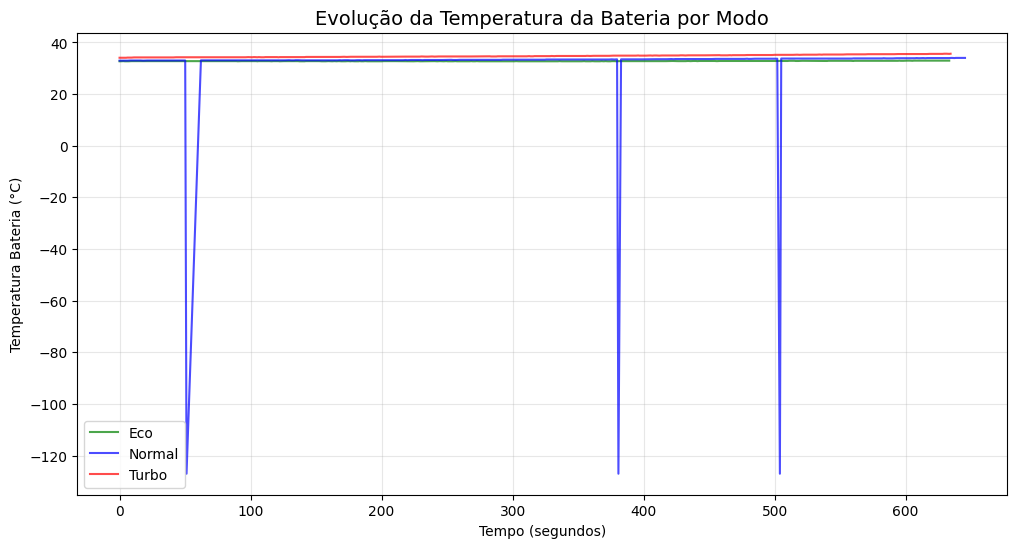

/tmp/ipykernel_13662/578719401.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='mode', y='temp_battery', data=df, palette='viridis')


-> Gráfico salvo: battery_eda_boxplot_temp_escalar.png


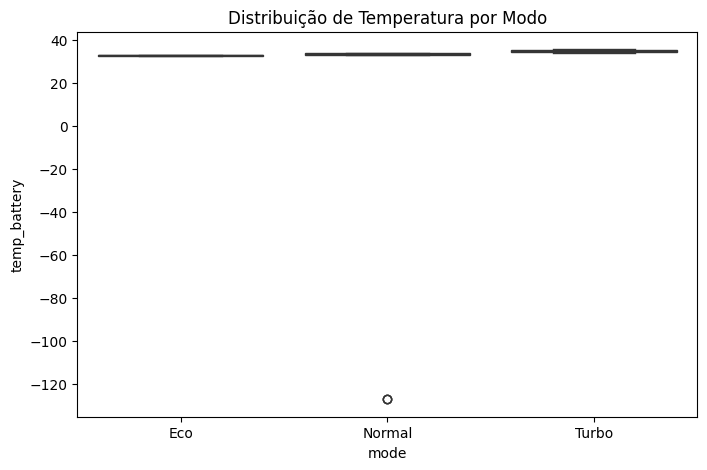

-> Gráfico salvo: battery_eda_correlacao_escalar.png


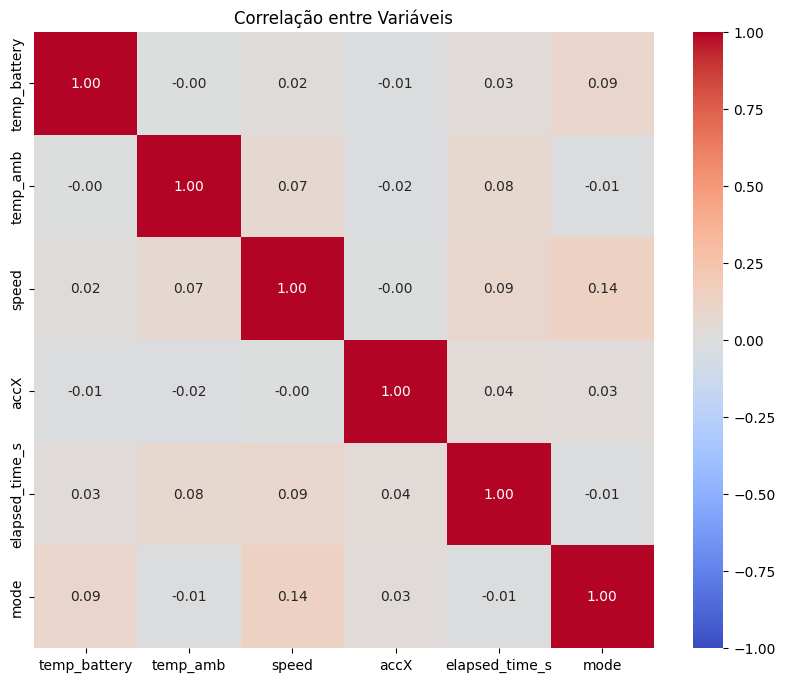

-> Gráfico salvo: battery_eda_distribuicao_escalar.png


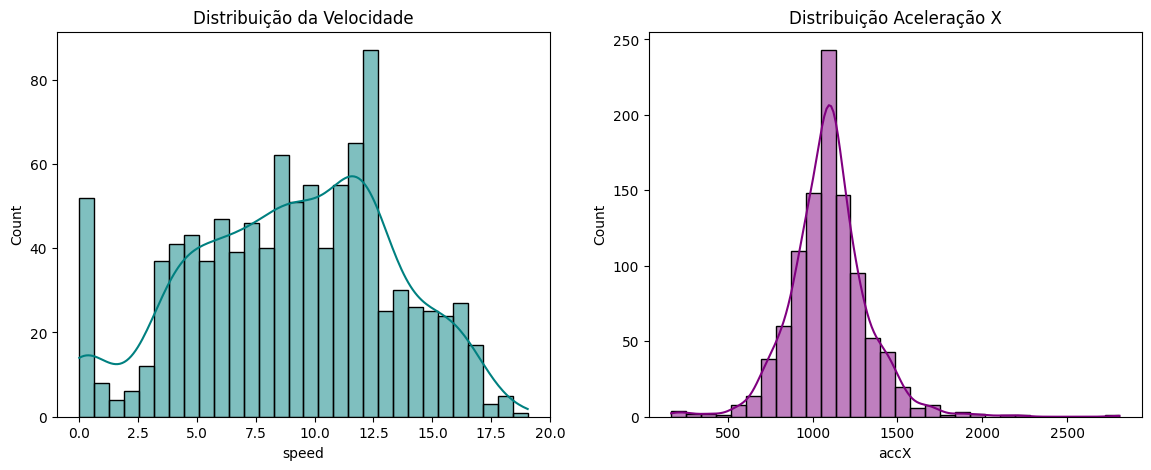

In [6]:
print("\n[Estatísticas Descritivas]")
print(df[['temp_battery', 'speed', 'accX', 'temp_amb']].describe().T)

print("\n[Checagem de Zeros (Possíveis falhas de sensor)]")
zeros_speed = (df['speed'] == 0).sum()
zeros_gps = ((df['lat'] == 0) & (df['lon'] == 0)).sum()
print(f"Registros com Velocidade = 0: {zeros_speed} ({zeros_speed/len(df):.1%})")
print(f"Registros com GPS zerado (Lat/Lon=0): {zeros_gps} ({zeros_gps/len(df):.1%})")

# Gráfico: Evolução da Temperatura por Modo
plt.figure(figsize=(12, 6))
modes = {0: 'Eco', 1: 'Normal', 2: 'Turbo'}
colors = {0: 'green', 1: 'blue', 2: 'red'}

for m_code, m_name in modes.items():
    subset = df[df['mode'] == m_code]
    plt.plot(subset['elapsed_time_s'], subset['temp_battery'], label=m_name, color=colors[m_code], alpha=0.7)

plt.title('Evolução da Temperatura da Bateria por Modo', fontsize=14)
plt.xlabel('Tempo (segundos)')
plt.ylabel('Temperatura Bateria (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../images/battery_eda_evolucao_temp_escalar.png')
print("-> Gráfico salvo: battery_eda_evolucao_temp_escalar.png")
plt.show()
plt.close()

# Gráfico: Boxplot Comparativo
plt.figure(figsize=(8, 5))
sns.boxplot(x='mode', y='temp_battery', data=df, palette='viridis')
plt.xticks([0, 1, 2], ['Eco', 'Normal', 'Turbo'])
plt.title('Distribuição de Temperatura por Modo')
plt.savefig('../images/battery_eda_boxplot_temp_escalar.png')
print("-> Gráfico salvo: battery_eda_boxplot_temp_escalar.png")
plt.show()
plt.close()

# Gráfico: Matriz de Correlação
plt.figure(figsize=(10, 8))
cols_corr = ['temp_battery', 'temp_amb', 'speed', 'accX', 'elapsed_time_s', 'mode']
corr = df[cols_corr].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlação entre Variáveis')
plt.savefig('../images/battery_eda_correlacao_escalar.png')
print("-> Gráfico salvo: battery_eda_correlacao_escalar.png")
plt.show()
plt.close()

# Histograma de Velocidade e Aceleração
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['speed'], bins=30, kde=True, ax=ax[0], color='teal')
ax[0].set_title('Distribuição da Velocidade')
sns.histplot(df['accX'], bins=30, kde=True, ax=ax[1], color='purple')
ax[1].set_title('Distribuição Aceleração X')
plt.savefig('../images/battery_eda_distribuicao_escalar.png')
print("-> Gráfico salvo: battery_eda_distribuicao_escalar.png")
plt.show()
plt.close()

## Treinamento e Predição - Valores escalares

In [7]:
features = ['mode', 'temp_amb', 'speed', 'accX', 'accY', 'accZ', 'elapsed_time_s']
target = 'temp_battery'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []

def run_model(model, name, param_dist):
    print(f"Treinando {name}...")
    random_search = RandomizedSearchCV(model, param_dist, n_iter=10, cv=3, 
                                     scoring='neg_mean_squared_error', 
                                     random_state=42, n_jobs=-1)
    
    start_total = time.time()
    
    # Monitoramento Treino
    with MonitorHardware(f"Treino_{name}") as mon_t:
        random_search.fit(X_train_scaled, y_train)
    
    time_train = time.time() - start_total
    best_model = random_search.best_estimator_
    
    # Monitoramento Predição
    start_pred = time.time()
    with MonitorHardware(f"Pred_{name}") as mon_p:
        y_pred = best_model.predict(X_test_scaled)
    time_pred = time.time() - start_pred
    
    # Métricas
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "Modelo": name,
        "R²": r2, "MAE": mae, "RMSE": rmse,
        "Tempo Treino": time_train,
        "CPU (%)": mon_t.dados['cpu_avg'],
        "RAM (MB)": mon_t.dados['ram_max'],
        "Melhor Config": str(random_search.best_params_)
    })
    print(f""""Modelo": {name},
        "R²": {r2}, "MAE": {mae}, "RMSE": {rmse},
        "Tempo Treino": {time_train},
        "CPU (%)": {mon_t.dados['cpu_avg']},
        "RAM (MB)": {mon_t.dados['ram_max']},
        "Melhor Config": {str(random_search.best_params_)}""")

Treinando KNN...
[Treino_KNN] CPU Méd: 2.3% (Max: 8.8%) | RAM Méd: 1130.5MB (Max: 1661.7MB)
[Pred_KNN] CPU Méd: 8.8% (Max: 8.8%) | RAM Méd: 1661.9MB (Max: 1661.9MB)
"Modelo": KNN,
        "R²": -5.250975310243467, "MAE": 0.6176630351681066, "RMSE": 2.1753113291150936,
        "Tempo Treino": 3.442340850830078,
        "CPU (%)": 2.2583333333333333,
        "RAM (MB)": 1661.66796875,
        "Melhor Config": {'weights': 'distance', 'n_neighbors': 19, 'metric': 'euclidean'}
Treinando DecisionTree...
[Treino_DecisionTree] CPU Méd: 6.9% (Max: 7.6%) | RAM Méd: 1679.0MB (Max: 1679.1MB)
[Pred_DecisionTree] CPU Méd: 0.0% (Max: 0.0%) | RAM Méd: 0.0MB (Max: 0.0MB)
"Modelo": DecisionTree,
        "R²": 0.9987162694684435, "MAE": 0.01430693069306931, "RMSE": 0.031173421022047225,
        "Tempo Treino": 0.3572971820831299,
        "CPU (%)": 6.945833333333333,
        "RAM (MB)": 1679.13671875,
        "Melhor Config": {'min_samples_split': 8, 'min_samples_leaf': 3, 'max_depth': 15, 'criterion': '

/home/katharian/.local/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/katharian/.local/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain f

[Treino_GradientBoosting] CPU Méd: 16.7% (Max: 95.3%) | RAM Méd: 1872.7MB (Max: 1899.0MB)
[Pred_GradientBoosting] CPU Méd: 69.2% (Max: 69.2%) | RAM Méd: 1899.0MB (Max: 1899.0MB)
"Modelo": GradientBoosting,
        "R²": -1.6722788377545488, "MAE": 0.5995756798923607, "RMSE": 1.422290850029504,
        "Tempo Treino": 1.7792794704437256,
        "CPU (%)": 16.7474358974359,
        "RAM (MB)": 1899.0234375,
        "Melhor Config": {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Treinando MLP...


/home/katharian/.local/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/katharian/.local/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/katharian/.local/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/katharian/.local/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/katharian/.local/lib/python3.8

[Treino_MLP] CPU Méd: 14.1% (Max: 98.6%) | RAM Méd: 1909.6MB (Max: 1911.3MB)
[Pred_MLP] CPU Méd: 93.2% (Max: 93.2%) | RAM Méd: 1911.3MB (Max: 1911.3MB)
"Modelo": MLP,
        "R²": -0.28904911319676696, "MAE": 0.8326815414586063, "RMSE": 0.9878301154148103,
        "Tempo Treino": 25.822240352630615,
        "CPU (%)": 14.052094474153298,
        "RAM (MB)": 1911.26953125,
        "Melhor Config": {'solver': 'adam', 'learning_rate_init': 0.001, 'hidden_layer_sizes': (50,), 'alpha': 0.01, 'activation': 'tanh'}

=== TABELA FINAL DE RESULTADOS ===
          Modelo        R²      MAE     RMSE  Tempo Treino   CPU (%)    RAM (MB)
    DecisionTree  0.998716 0.014307 0.031173      0.357297  6.945833 1679.136719
             MLP -0.289049 0.832682 0.987830     25.822240 14.052094 1911.269531
GradientBoosting -1.672279 0.599576 1.422291      1.779279 16.747436 1899.023438
    RandomForest -2.921464 0.702375 1.722946      2.496941  2.575000 1751.449219
             KNN -5.250975 0.617663 2.175311

/tmp/ipykernel_13662/3157379178.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R²', y='Modelo', data=results_df, palette='viridis')


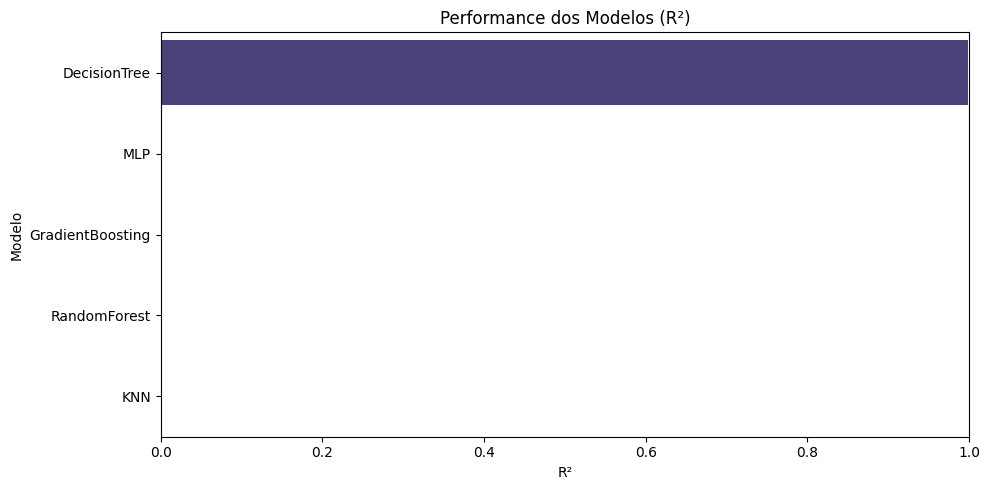

Resultados salvos em 'resultados_finais_train_escalar.csv' e 'performance_modelos.png'


In [8]:
run_model(KNeighborsRegressor(), "KNN", {
    'n_neighbors': np.arange(3, 21, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
})

run_model(DecisionTreeRegressor(random_state=42), "DecisionTree", {
    'max_depth': [None] + list(np.arange(5, 30, 5)),
    'min_samples_split': np.arange(2, 11, 2),
    'min_samples_leaf': np.arange(1, 11, 2),
    'criterion': ['squared_error', 'absolute_error']
})

run_model(RandomForestRegressor(random_state=42), "RandomForest", {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
})

run_model(XGBRegressor(random_state=42), "GradientBoosting", {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
})

run_model(MLPRegressor(random_state=42, max_iter=1000), "MLP", {
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
})

# Resultados Finais
results_df = pd.DataFrame(results).sort_values(by="R²", ascending=False)
print("\n=== TABELA FINAL DE RESULTADOS ===")
print(results_df[['Modelo', 'R²', 'MAE', 'RMSE', 'Tempo Treino', 'CPU (%)', 'RAM (MB)']].to_string(index=False))

# Salvar
results_df.to_csv('battery_resultados_finais_train_escalar.csv', index=False)
plt.figure(figsize=(10, 5))
sns.barplot(x='R²', y='Modelo', data=results_df, palette='viridis')
plt.title('Performance dos Modelos (R²)')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('../images/battery_performance_modelos_escalar.png')
plt.show()
print("Resultados salvos em 'resultados_finais_train_escalar.csv' e 'performance_modelos.png'")

## Treinamento e Predição - Médias Móveis

In [9]:
# ==============================================================================
# NOVA ETAPA: Engenharia de Features (Criando Memória para o Modelo)
# ==============================================================================
print("--- Gerando Features de Inércia Térmica ---")

# Garantir que está ordenado por tempo para os cálculos funcionarem
df = df.sort_values(by=['mode', 'elapsed_time_s'])

# 1. Médias Móveis
# Janelas de 30s e 60s para Velocidade e Aceleração (Magnitude)
df['acc_mag'] = np.sqrt(df['accX']**2 + df['accY']**2 + df['accZ']**2) # Magnitude da aceleração

for window in [30, 60, 120]: # Janelas de 30s, 1min e 2min
    # Média da velocidade nos últimos X segundos
    df[f'speed_roll_mean_{window}'] = df.groupby('mode')['speed'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    # Média da aceleração nos últimos X segundos (esforço)
    df[f'acc_roll_mean_{window}'] = df.groupby('mode')['acc_mag'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )

# 2. Energia Acumulada (Integral aproximada)
# Soma cumulativa de Velocidade (distância teórica) e Aceleração (esforço total)
df['speed_cumsum'] = df.groupby('mode')['speed'].cumsum()
df['acc_cumsum'] = df.groupby('mode')['acc_mag'].cumsum()

# 3. Diferença de Temperatura Ambiente
# O quão mais quente que o ambiente a bateria já está? (Se tiver essa info no início)
# Como não temos temp anterior, vamos usar o tempo decorrido como fator de "fator de aquecimento"
df['heating_factor'] = df['elapsed_time_s'] * df['speed_roll_mean_60'] 

# Atualizar lista de features para o treinamento
features = [
    'mode', 'temp_amb', 'elapsed_time_s',
    'speed_roll_mean_30', 'speed_roll_mean_60', 'speed_roll_mean_120',
    'acc_roll_mean_30', 'acc_roll_mean_60',
    'speed_cumsum', 'acc_cumsum', 'heating_factor'
]
# Note que removemos 'speed', 'accX', etc. instantâneos, pois eles são ruído.
# Mantivemos 'elapsed_time_s' pois o tempo total é crucial para aquecimento.

target = 'temp_battery'

print(f"Novas Features geradas: {features}")
df = df.dropna() # Remove linhas iniciais que podem ter ficado vazias no rolling

--- Gerando Features de Inércia Térmica ---
Novas Features geradas: ['mode', 'temp_amb', 'elapsed_time_s', 'speed_roll_mean_30', 'speed_roll_mean_60', 'speed_roll_mean_120', 'acc_roll_mean_30', 'acc_roll_mean_60', 'speed_cumsum', 'acc_cumsum', 'heating_factor']


Treinando KNN...
[Treino_KNN] CPU Méd: 8.7% (Max: 8.7%) | RAM Méd: 1914.8MB (Max: 1914.8MB)
[Pred_KNN] CPU Méd: 13.0% (Max: 13.0%) | RAM Méd: 1914.8MB (Max: 1914.8MB)
"Modelo": KNN,
        "R²": -7.42811666139338, "MAE": 0.5283210379776057, "RMSE": 2.5258804941520276,
        "Tempo Treino": 0.3377864360809326,
        "CPU (%)": 8.733333333333333,
        "RAM (MB)": 1914.7890625,
        "Melhor Config": {'weights': 'distance', 'n_neighbors': 19, 'metric': 'euclidean'}
Treinando DecisionTree...
[Treino_DecisionTree] CPU Méd: 6.4% (Max: 9.2%) | RAM Méd: 1914.8MB (Max: 1914.8MB)
[Pred_DecisionTree] CPU Méd: 0.0% (Max: 0.0%) | RAM Méd: 0.0MB (Max: 0.0MB)
"Modelo": DecisionTree,
        "R²": 0.999046521082522, "MAE": 0.01099009900990095, "RMSE": 0.02686600413566956,
        "Tempo Treino": 0.4664037227630615,
        "CPU (%)": 6.422222222222222,
        "RAM (MB)": 1914.796875,
        "Melhor Config": {'min_samples_split': 8, 'min_samples_leaf': 3, 'max_depth': 15, 'criterion': 'abso

/home/katharian/.local/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/katharian/.local/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/katharian/.local/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/katharian/.local/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/katharian/.local/lib/python3.8

[Treino_MLP] CPU Méd: 12.6% (Max: 95.7%) | RAM Méd: 1927.9MB (Max: 1928.1MB)
[Pred_MLP] CPU Méd: 0.0% (Max: 0.0%) | RAM Méd: 0.0MB (Max: 0.0MB)
"Modelo": MLP,
        "R²": -4.957104060457404, "MAE": 1.7735994820544696, "RMSE": 2.1235628698878277,
        "Tempo Treino": 19.800377368927002,
        "CPU (%)": 12.620277777777776,
        "RAM (MB)": 1928.10546875,
        "Melhor Config": {'solver': 'adam', 'learning_rate_init': 0.001, 'hidden_layer_sizes': (50,), 'alpha': 0.0001, 'activation': 'tanh'}

=== TABELA FINAL DE RESULTADOS ===
          Modelo        R²      MAE     RMSE  Tempo Treino   CPU (%)    RAM (MB)
    DecisionTree  0.999047 0.010990 0.026866      0.466404  6.422222 1914.796875
GradientBoosting  0.027220 0.439906 0.858134    109.876366 74.991514 1939.722656
    RandomForest -1.441921 0.429206 1.359607      3.796204  2.959409 1915.679688
             MLP -4.957104 1.773599 2.123563     19.800377 12.620278 1928.105469
             KNN -7.428117 0.528321 2.525880      0.

/tmp/ipykernel_13662/2342731013.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R²', y='Modelo', data=results_df, palette='viridis')


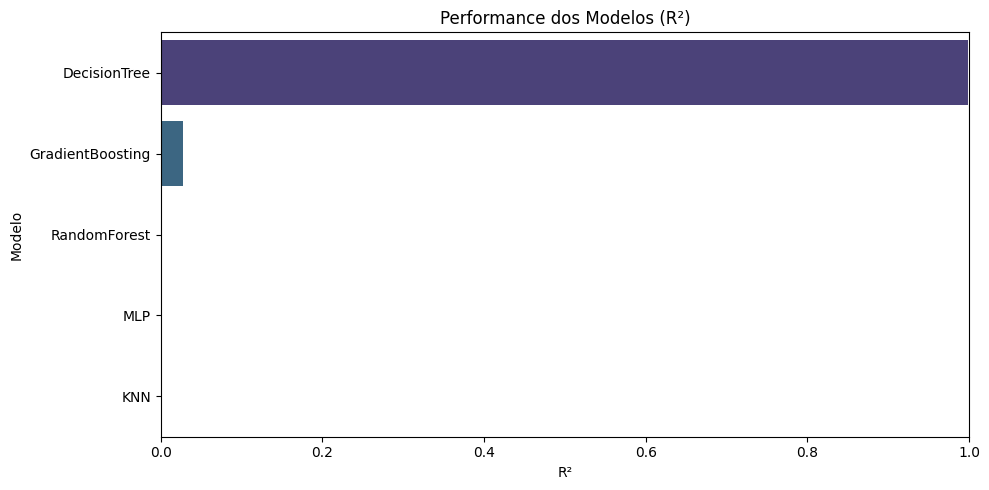

Resultados salvos em 'resultados_finais_train_media.csv' e 'performance_modelos.png'


In [10]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []

run_model(KNeighborsRegressor(), "KNN", {
    'n_neighbors': np.arange(3, 21, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
})

run_model(DecisionTreeRegressor(random_state=42), "DecisionTree", {
    'max_depth': [None] + list(np.arange(5, 30, 5)),
    'min_samples_split': np.arange(2, 11, 2),
    'min_samples_leaf': np.arange(1, 11, 2),
    'criterion': ['squared_error', 'absolute_error']
})

run_model(RandomForestRegressor(random_state=42), "RandomForest", {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
})

run_model(XGBRegressor(random_state=42), "GradientBoosting", {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
})

run_model(MLPRegressor(random_state=42, max_iter=1000), "MLP", {
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
})

# Resultados Finais
results_df = pd.DataFrame(results).sort_values(by="R²", ascending=False)
print("\n=== TABELA FINAL DE RESULTADOS ===")
print(results_df[['Modelo', 'R²', 'MAE', 'RMSE', 'Tempo Treino', 'CPU (%)', 'RAM (MB)']].to_string(index=False))

# Salvar
results_df.to_csv('battery_resultados_finais_train_media.csv', index=False)
plt.figure(figsize=(10, 5))
sns.barplot(x='R²', y='Modelo', data=results_df, palette='viridis')
plt.title('Performance dos Modelos (R²)')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('../images/battery_performance_modelos_media.png')
plt.show()
print("Resultados salvos em 'resultados_finais_train_media.csv' e 'performance_modelos.png'")

# Usando dados tratados (Sem outliers)

## Reprocessando os dados

In [11]:
files = [
    "../data/processed/teste_eco_10_01_4.csv",
    "../data/processed/teste_nor_10_01.csv",
    "../data/processed/teste_tur_10_01.csv"
]

df_list = []
for file_path in files:
    try:
        temp_df = pd.read_csv(file_path)
        df_list.append(temp_df)
        print(f"Carregado: {file_path}")
    except FileNotFoundError:
        print(f"ERRO: Arquivo {file_path} não encontrado.")

if not df_list:
    raise ValueError("Nenhum arquivo foi carregado. Verifique os caminhos.")

df = pd.concat(df_list, ignore_index=True)

# Mapear os modos para valores numéricos
def map_mode(val):
    val = str(val).lower()
    if 'eco' in val: return 0
    if 'nor' in val: return 1
    if 'tur' in val: return 2
    return -1 # Caso de erro

df['mode'] = df['testCase'].apply(map_mode)

# Calcular o tempo decorrido em segundos desde o início de teste em cada modo
df = df.sort_values(by=['testCase', 'receivedAtMs'])
df['elapsed_time_s'] = df.groupby('testCase')['receivedAtMs'].transform(lambda x: (x - x.min()) / 1000.0)

#Deixando só as colunas relevantes
cols_to_drop = ['id', 'deviceId', 'sampleId', 'motorC', 'testCase', 
                'receivedAt', 'receivedAtMs', 'headingDeg', 'accuracyM']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

#Removendo outliers de temperatura da bateria (falha na coleta)
df = df.dropna(subset=['batteryC'])
df = df[ (df['batteryC'] > 0) & (df['batteryC'] < 150) ]

df = df.rename(columns={
    'referenceC': 'temp_amb',
    'speedMps': 'speed',
    'lng': 'lon',
    'accel_x': 'accX', 
    'accel_y': 'accY', 
    'accel_z': 'accZ',
    'batteryC': 'temp_battery'
})

print(f"Dataset processado: {df.shape[0]} registros.")
df.head()

Carregado: ../data/processed/teste_eco_10_01_4.csv
Carregado: ../data/processed/teste_nor_10_01.csv
Carregado: ../data/processed/teste_tur_10_01.csv
Dataset processado: 1007 registros.


,lat,lon,speed,temp_battery,temp_amb,accX,accY,accZ,mode,elapsed_time_s
0,-8.055623,-34.951128,0.000000,32.69,30.44,1084,332,165,0,0.000
1,-8.055622,-34.951125,0.000000,32.69,30.44,1094,333,130,0,1.022
2,-8.055609,-34.951112,0.740566,32.75,30.50,1093,334,134,0,2.998
3,-8.055603,-34.951105,0.394090,32.69,30.50,1094,333,137,0,4.022
4,-8.055606,-34.951103,0.561951,32.69,30.56,1093,332,132,0,7.139


## Análise exploratória


[Estatísticas Descritivas]
               count         mean         std     min         25%  \
temp_battery  1007.0    33.662483    0.886325   32.69   32.810000   
speed         1007.0     9.025323    4.273327    0.00    5.865584   
accX          1007.0  1096.756703  232.959043  167.00  970.000000   
temp_amb      1007.0    31.727140    5.030720 -127.00   31.560000   

                      50%          75%          max  
temp_battery    33.380000    34.380000    35.620000  
speed            9.309973    12.169084    19.051404  
accX          1097.000000  1207.500000  2808.000000  
temp_amb        31.880000    32.250000    33.120000  

[Checagem de Zeros (Possíveis falhas de sensor)]
Registros com Velocidade = 0: 30 (3.0%)
Registros com GPS zerado (Lat/Lon=0): 0 (0.0%)
-> Gráfico salvo: battery_eda_evolucao_temp_tratados.png


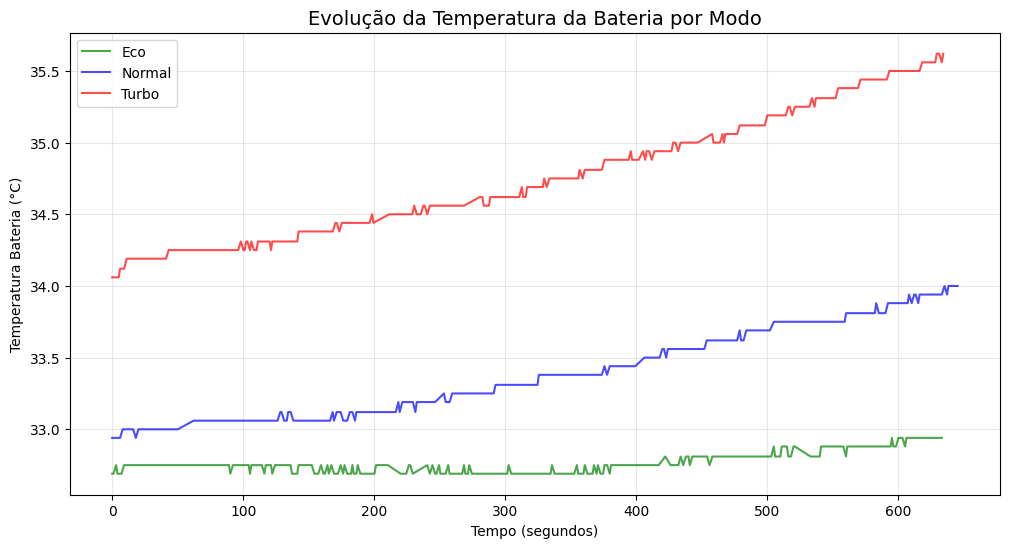

/tmp/ipykernel_13662/1488344317.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='mode', y='temp_battery', data=df, palette='viridis')


-> Gráfico salvo: battery_eda_boxplot_temp_tratados.png


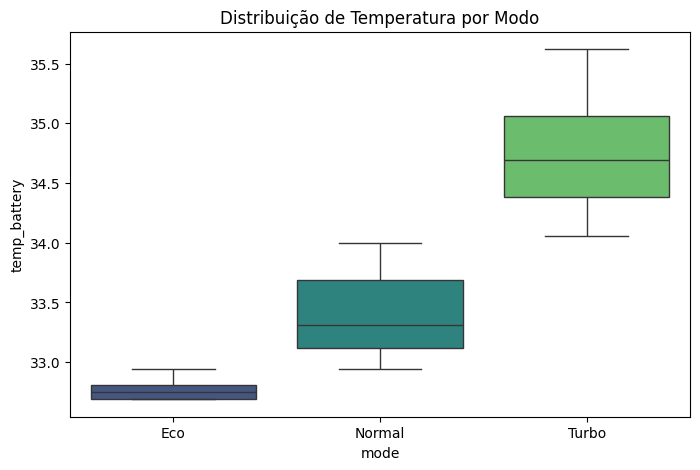

-> Gráfico salvo: battery_eda_correlacao_tratados.png


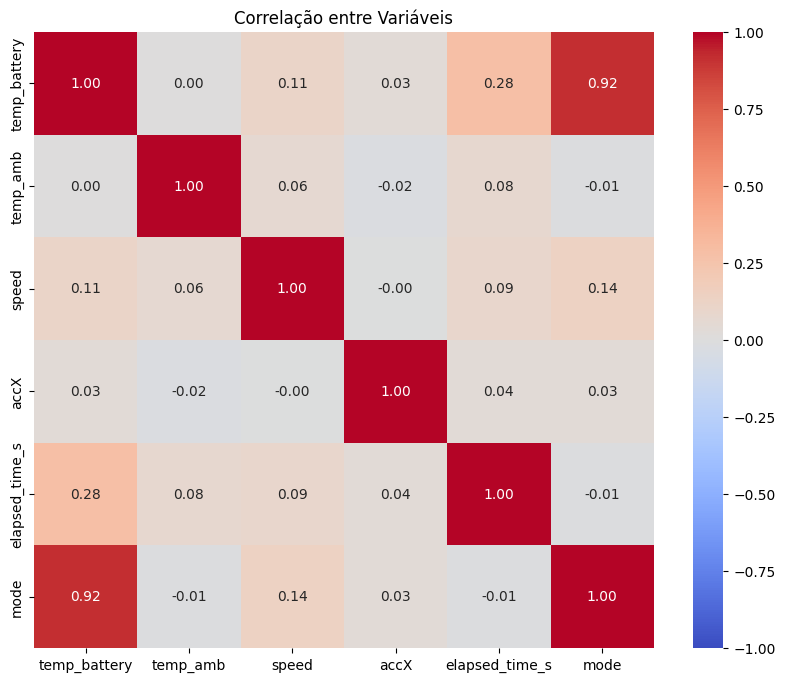

-> Gráfico salvo: battery_eda_distribuicao_tratados.png


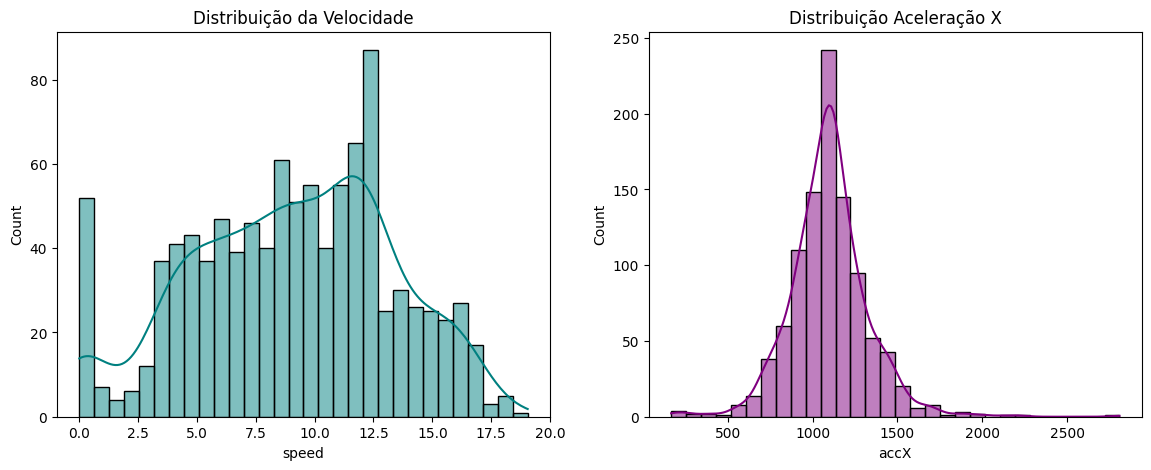

In [12]:
print("\n[Estatísticas Descritivas]")
print(df[['temp_battery', 'speed', 'accX', 'temp_amb']].describe().T)

print("\n[Checagem de Zeros (Possíveis falhas de sensor)]")
zeros_speed = (df['speed'] == 0).sum()
zeros_gps = ((df['lat'] == 0) & (df['lon'] == 0)).sum()
print(f"Registros com Velocidade = 0: {zeros_speed} ({zeros_speed/len(df):.1%})")
print(f"Registros com GPS zerado (Lat/Lon=0): {zeros_gps} ({zeros_gps/len(df):.1%})")

# Gráfico: Evolução da Temperatura por Modo
plt.figure(figsize=(12, 6))
modes = {0: 'Eco', 1: 'Normal', 2: 'Turbo'}
colors = {0: 'green', 1: 'blue', 2: 'red'}

for m_code, m_name in modes.items():
    subset = df[df['mode'] == m_code]
    plt.plot(subset['elapsed_time_s'], subset['temp_battery'], label=m_name, color=colors[m_code], alpha=0.7)

plt.title('Evolução da Temperatura da Bateria por Modo', fontsize=14)
plt.xlabel('Tempo (segundos)')
plt.ylabel('Temperatura Bateria (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../images/battery_eda_evolucao_temp_tratados.png')
print("-> Gráfico salvo: battery_eda_evolucao_temp_tratados.png")
plt.show()
plt.close()

# Gráfico: Boxplot Comparativo
plt.figure(figsize=(8, 5))
sns.boxplot(x='mode', y='temp_battery', data=df, palette='viridis')
plt.xticks([0, 1, 2], ['Eco', 'Normal', 'Turbo'])
plt.title('Distribuição de Temperatura por Modo')
plt.savefig('../images/battery_eda_boxplot_temp_tratados.png')
print("-> Gráfico salvo: battery_eda_boxplot_temp_tratados.png")
plt.show()
plt.close()

# Gráfico: Matriz de Correlação
plt.figure(figsize=(10, 8))
cols_corr = ['temp_battery', 'temp_amb', 'speed', 'accX', 'elapsed_time_s', 'mode']
corr = df[cols_corr].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlação entre Variáveis')
plt.savefig('../images/battery_eda_correlacao_tratados.png')
print("-> Gráfico salvo: battery_eda_correlacao_tratados.png")
plt.show()
plt.close()

# Histograma de Velocidade e Aceleração
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['speed'], bins=30, kde=True, ax=ax[0], color='teal')
ax[0].set_title('Distribuição da Velocidade')
sns.histplot(df['accX'], bins=30, kde=True, ax=ax[1], color='purple')
ax[1].set_title('Distribuição Aceleração X')
plt.savefig('../images/battery_eda_distribuicao_tratados.png')
print("-> Gráfico salvo: battery_eda_distribuicao_tratados.png")
plt.show()
plt.close()

## Treinamento e Predição

Treinando KNN...
[Treino_KNN] CPU Méd: 8.7% (Max: 8.7%) | RAM Méd: 1934.9MB (Max: 1934.9MB)
[Pred_KNN] CPU Méd: 12.1% (Max: 12.1%) | RAM Méd: 1934.9MB (Max: 1934.9MB)
"Modelo": KNN,
        "R²": 0.9747042523716689, "MAE": 0.07250562254269642, "RMSE": 0.1370119089852397,
        "Tempo Treino": 0.21303701400756836,
        "CPU (%)": 8.658333333333333,
        "RAM (MB)": 1934.89453125,
        "Melhor Config": {'weights': 'distance', 'n_neighbors': 3, 'metric': 'manhattan'}
Treinando DecisionTree...
[Treino_DecisionTree] CPU Méd: 8.1% (Max: 10.5%) | RAM Méd: 1934.9MB (Max: 1934.9MB)
[Pred_DecisionTree] CPU Méd: 0.0% (Max: 0.0%) | RAM Méd: 0.0MB (Max: 0.0MB)
"Modelo": DecisionTree,
        "R²": 0.9991471061800377, "MAE": 0.012711221122113904, "RMSE": 0.0251583434316417,
        "Tempo Treino": 0.2848935127258301,
        "CPU (%)": 8.141666666666667,
        "RAM (MB)": 1934.90625,
        "Melhor Config": {'min_samples_split': 2, 'min_samples_leaf': 3, 'max_depth': None, 'criterion':

/home/katharian/.local/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/katharian/.local/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/katharian/.local/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/katharian/.local/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/katharian/.local/lib/python3.8

[Treino_MLP] CPU Méd: 2.1% (Max: 9.8%) | RAM Méd: 1955.7MB (Max: 1955.8MB)
[Pred_MLP] CPU Méd: 7.7% (Max: 7.7%) | RAM Méd: 1955.8MB (Max: 1955.8MB)
"Modelo": MLP,
        "R²": 0.9899432333934987, "MAE": 0.06520178412314999, "RMSE": 0.08639005354480662,
        "Tempo Treino": 16.017313957214355,
        "CPU (%)": 2.1423245614035094,
        "RAM (MB)": 1955.8359375,
        "Melhor Config": {'solver': 'adam', 'learning_rate_init': 0.01, 'hidden_layer_sizes': (50, 25), 'alpha': 0.001, 'activation': 'tanh'}

=== TABELA FINAL DE RESULTADOS ===
          Modelo       R²      MAE     RMSE  Tempo Treino   CPU (%)    RAM (MB)
    RandomForest 0.999400 0.012405 0.021104      2.741067  3.181349 1934.906250
    DecisionTree 0.999147 0.012711 0.025158      0.284894  8.141667 1934.906250
GradientBoosting 0.998552 0.022522 0.032784      3.092041 36.386594 1955.644531
             MLP 0.989943 0.065202 0.086390     16.017314  2.142325 1955.835938
             KNN 0.974704 0.072506 0.137012      0.

/tmp/ipykernel_13662/1939612204.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R²', y='Modelo', data=results_df, palette='viridis')


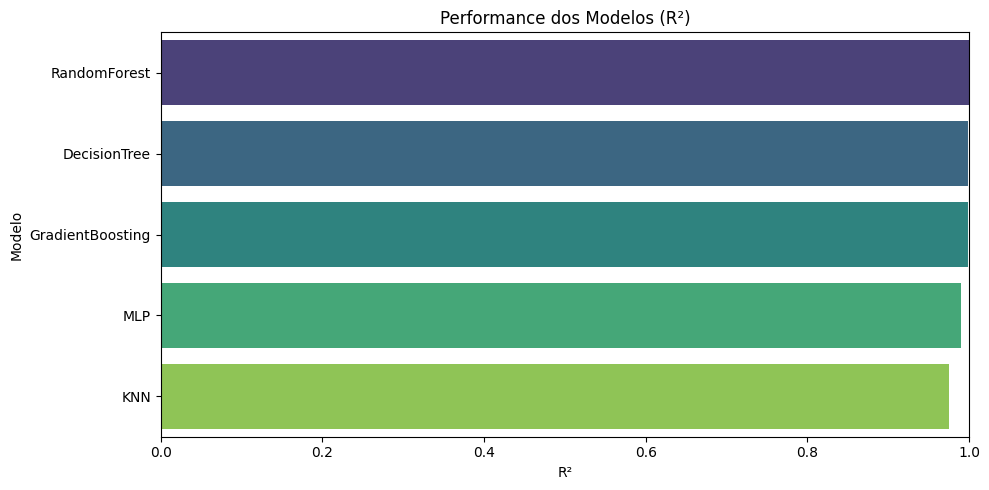

Resultados salvos em 'resultados_finais_train_tratados.csv' e 'performance_modelos.png'


In [13]:
features = ['mode', 'temp_amb', 'speed', 'accX', 'accY', 'accZ', 'elapsed_time_s']
target = 'temp_battery'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []

run_model(KNeighborsRegressor(), "KNN", {
    'n_neighbors': np.arange(3, 21, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
})

run_model(DecisionTreeRegressor(random_state=42), "DecisionTree", {
    'max_depth': [None] + list(np.arange(5, 30, 5)),
    'min_samples_split': np.arange(2, 11, 2),
    'min_samples_leaf': np.arange(1, 11, 2),
    'criterion': ['squared_error', 'absolute_error']
})

run_model(RandomForestRegressor(random_state=42), "RandomForest", {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
})

run_model(XGBRegressor(random_state=42), "GradientBoosting", {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
})

run_model(MLPRegressor(random_state=42, max_iter=1000), "MLP", {
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
})

# Resultados Finais
results_df = pd.DataFrame(results).sort_values(by="R²", ascending=False)
print("\n=== TABELA FINAL DE RESULTADOS ===")
print(results_df[['Modelo', 'R²', 'MAE', 'RMSE', 'Tempo Treino', 'CPU (%)', 'RAM (MB)']].to_string(index=False))

# Salvar
results_df.to_csv('battery_resultados_finais_train_tratados.csv', index=False)
plt.figure(figsize=(10, 5))
sns.barplot(x='R²', y='Modelo', data=results_df, palette='viridis')
plt.title('Performance dos Modelos (R²)')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('../images/battery_performance_modelos_tratados.png')
plt.show()
print("Resultados salvos em 'resultados_finais_train_tratados.csv' e 'performance_modelos.png'")